# 02 - GPT Training: tensorgrad vs PyTorch

Comparison run on Shakespeare. Both models tensorgrad and a PyTorch
reference train for 5 000 steps with identical hyperparameters, the same
data batches (fixed numpy seed), and the same init scheme. The tensorgrad
model uses a pre-norm architecture with combined `c_attn` projection,
cosine LR decay, and gradient clipping (global norm =< 1.0).

Results were pre-saved by `examples/train_gpt.py`. This notebook just loads
the histories and the checkpoint no retraining.

## 0. Environment setup

In [2]:
import os, sys, json, urllib.request
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

# notebooks/ is one level below the project root
PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)

from tensorgrad.nn import GPTNano

OUT_DIR   = os.path.join(PROJECT_ROOT, 'outputs')
CKPT_PATH = os.path.join(OUT_DIR, 'checkpoints', 'tg_model.npz')

print(f"Project root : {PROJECT_ROOT}")
print(f"NumPy        : {np.__version__}")
print(f"Checkpoint   : {'found' if os.path.exists(CKPT_PATH) else 'MISSING — run examples/train_gpt.py first'}")

Project root : /Users/nurtaabaldiev/Documents/Ml_Projects/tensorgrad
NumPy        : 2.3.4
Checkpoint   : found


## 1. Hyperparameters

In [4]:
HP = dict(
    # model architecture
    n_embd      = 256,
    n_head      = 4,
    n_layer     = 4,
    block_size  = 64,
    # training schedule
    batch_size    = 32,
    max_iters     = 5000,
    eval_interval = 100,
    eval_iters    = 50,
    # optimiser
    lr            = 3e-3,       
    weight_decay  = 0.1,
    # data
    train_split   = 0.9,
    seed          = 1337,
)

for k, v in HP.items():
    print(f"  {k:<16} {v}")

  n_embd           256
  n_head           4
  n_layer          4
  block_size       64
  batch_size       32
  max_iters        5000
  eval_interval    100
  eval_iters       50
  lr               0.003
  weight_decay     0.1
  train_split      0.9
  seed             1337


## 2. Data: load and tokenize Shakespeare

In [5]:
DATA_URL  = ("https://raw.githubusercontent.com/karpathy/char-rnn"
             "/master/data/tinyshakespeare/input.txt")
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'shakespeare.txt')

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
if not os.path.exists(DATA_PATH):
    print("Downloading Shakespeare...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH) as f:
    text = f.read()

chars      = sorted(set(text))
stoi       = {c: i for i, c in enumerate(chars)}
itos       = {i: c for c, i in stoi.items()}
vocab_size = len(chars)

HP['vocab_size'] = vocab_size

print(f"Text length  : {len(text):,} chars")
print(f"Vocab size   : {vocab_size}")
print(f"Uniform-init expected loss : {np.log(vocab_size):.4f} nats")

Text length  : 1,115,394 chars
Vocab size   : 65
Uniform-init expected loss : 4.1744 nats


## 3. Load saved training histories

In [7]:
json_dir = os.path.join(OUT_DIR, 'json')

with open(os.path.join(json_dir, 'tg_history.json')) as f:
    tg_history = json.load(f)

with open(os.path.join(json_dir, 'pt_history.json')) as f:
    pt_history = json.load(f)

tg_final = tg_history['val'][-1]
pt_final = pt_history['val'][-1]
diff     = abs(tg_final - pt_final)

print(f"Iterations logged : {tg_history['iter'][-1]}")
print()
print("val loss comparison (final)")
print("-" * 35)
print(f"  tensorgrad  {tg_final:.4f}")
print(f"  pytorch     {pt_final:.4f}")
print(f"  |diff|      {diff:.4f}  {'OK' if diff < 0.30 else 'LARGE check gradients'}")

Iterations logged : 5000

val loss comparison (final)
-----------------------------------
  tensorgrad  1.8467
  pytorch     1.8381
  |diff|      0.0085  OK


## 4. Loss curves

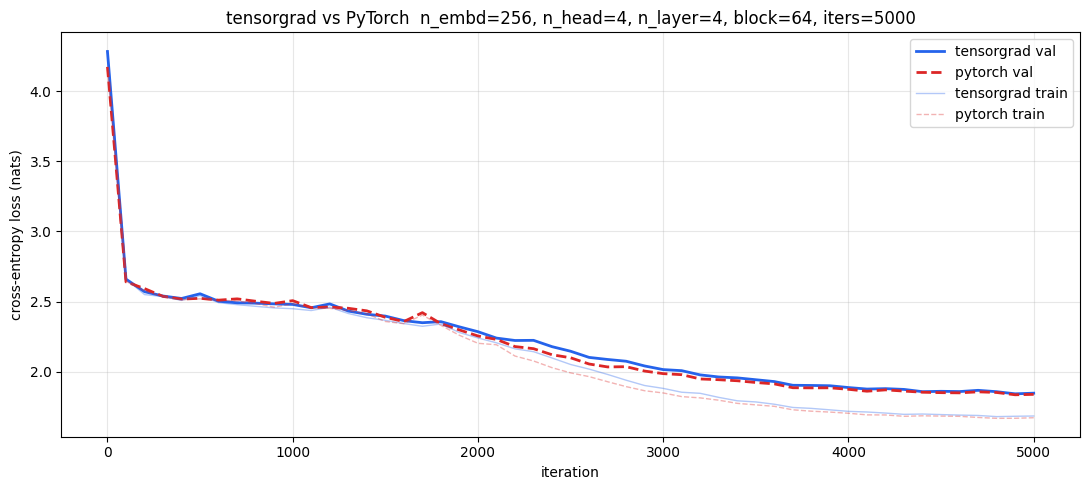

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

# Validation (solid, thick)
ax.plot(tg_history['iter'], tg_history['val'],   color='#2563eb', lw=2,
        label='tensorgrad val')
ax.plot(pt_history['iter'], pt_history['val'],   color='#dc2626', lw=2,
        linestyle='--', label='pytorch val')

# Training (faint)
ax.plot(tg_history['iter'], tg_history['train'], color='#2563eb', lw=1,
        alpha=0.35, label='tensorgrad train')
ax.plot(pt_history['iter'], pt_history['train'], color='#dc2626', lw=1,
        alpha=0.35, linestyle='--', label='pytorch train')

ax.set_xlabel('iteration')
ax.set_ylabel('cross-entropy loss (nats)')
ax.set_title(
    f"tensorgrad vs PyTorch  "
    f"n_embd={HP['n_embd']}, n_head={HP['n_head']}, "
    f"n_layer={HP['n_layer']}, block={HP['block_size']}, "
    f"iters={HP['max_iters']}"
)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Load tensorgrad model from checkpoint

Parameters were saved by `examples/train_gpt.py` after training as `p0, p1, p2, ...`  
in the same order as `model.parameters()`.  
We reinstantiate the architecture, then copy the arrays back in.

In [9]:
tg_model = GPTNano(
    vocab_size = HP['vocab_size'],
    n_embd     = HP['n_embd'],
    n_head     = HP['n_head'],
    n_layer    = HP['n_layer'],
    block_size = HP['block_size'],
)

ckpt   = np.load(CKPT_PATH)
params = list(tg_model.parameters())
for i, p in enumerate(params):
    p.data = ckpt[f'p{i}']

print(f"Loaded {len(params)} parameter tensors")
print(f"Total parameters : {tg_model.num_params():,}")
print(f"Val loss at save : {tg_final:.4f}")

Loaded 53 parameter tensors
Total parameters : 3,209,216
Val loss at save : 1.8467


## 6. Generate text

Temperature sampling (`T = 0.8`) instead of greedy argmax.  
Greedy always collapses to the most probable token at every step → "the the the the..."

At each step: `probs = softmax(logits / T)`, then sample from `Categorical(probs)`.

In [11]:
def generate(model, prompt='ROMEO:', n_chars=500, temperature=0.8, seed=42):
    rng     = np.random.default_rng(seed)
    ctx     = np.array([[stoi.get(c, 0) for c in prompt]], dtype=np.int64)
    out_ids = list(ctx[0])

    for _ in range(n_chars):
        x      = ctx[:, -model.block_size:]
        logits = model(x)
        last   = logits.data[0, -1]              # (vocab_size,) logits at last position
        shifted = (last - last.max()) / temperature
        probs   = np.exp(shifted)
        probs  /= probs.sum()
        tok     = int(rng.choice(len(probs), p=probs))
        out_ids.append(tok)
        ctx    = np.concatenate([ctx, [[tok]]], axis=1)

    return ''.join(itos[i] for i in out_ids)


sample = generate(tg_model, prompt='ROMEO:', n_chars=500, temperature=0.8)
print(sample)

ROMEO:
Looesth's with news: you lady, dember this to him I soul;
And thee and that soul, a brieffore plactions.



The nime mine land and pleaven, hour head?

HASTINGIS:
Now, when cantsipured have.

MENENIUS:
A ear one things gooods of courtors
Apole the his depreat them faid canot not
And make thoughter's of more me in lords.

Second Murderent with well bear to sube the,
When cate thou house? Dod my lords your you the sene?

First Shet falll come, man the curtions of you.


CAMILLLLO:
I god time more


Temperature 0.8 enough randomness to avoid repetition without
collapsing into incoherence. Not Shakespeare, but the model picks
up rough metre and punctuation after 5 000 steps on ~1M characters.